In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Re-load the DataFrame to ensure 'Attrition' is present and consistent
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 1. Missing Value Handling
# As per df.isnull().sum() output, there are no missing values in the dataset.
print("Missing values before handling:\n", df.isnull().sum().sum())

# 2. Duplicate Removal
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\nNumber of duplicate rows removed: {initial_rows - df.shape[0]}")

# 3. Encode Categorical Variables & Create Attrition Labels (Moved this up to ensure 'Attrition' is handled)
# Convert 'Attrition' to numerical (Yes=1, No=0)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
# Fill any NaNs that might have been introduced during mapping (e.g., if there were values other than 'Yes'/'No')
df['Attrition'] = df['Attrition'].fillna(0).astype(int)

# 4. Data Type Correction & Feature Formatting (Dropping constant/non-informative columns)
# 'EmployeeCount', 'StandardHours' have std dev of 0 (from df.describe()) and 'Over18' is often constant.
# Let's verify and drop them if they are indeed constant.
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nConstant columns identified and dropped: {constant_columns}")
df.drop(columns=constant_columns, inplace=True)

# Create a copy of the DataFrame for EDA plots that require original categorical columns
# before further one-hot encoding and scaling.
df_eda = df.copy() # df_eda now has numerical Attrition, but other categoricals are still objects

# Identify other categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns
print(f"\nCategorical columns to be one-hot encoded: {list(categorical_cols)}")
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Standardize Salary Ranges
salary_cols = ['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate']

# Check if these columns exist before trying to standardize
existing_salary_cols = [col for col in salary_cols if col in df.columns]

if existing_salary_cols:
    scaler = StandardScaler()
    df[existing_salary_cols] = scaler.fit_transform(df[existing_salary_cols])
    print(f"\nStandardized salary columns: {existing_salary_cols}")
else:
    print("\nNo salary columns found for standardization.")

# Display the first few rows of the preprocessed DataFrame and its info
print("\nDataFrame after preprocessing:")
print(df.head())
print("\nDataFrame Info after preprocessing:")
df.info()

Missing values before handling:
 0

Number of duplicate rows removed: 0

Constant columns identified and dropped: ['EmployeeCount', 'Over18', 'StandardHours']

Categorical columns to be one-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Standardized salary columns: ['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate']

DataFrame after preprocessing:
   Age  Attrition  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0   41          1   0.742527                 1          2               1   
1   49          0  -1.297775                 8          1               2   
2   37          1   1.414363                 2          2               4   
3   33          0   1.461466                 3          4               5   
4   27          0  -0.524295                 2          1               7   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  ...  \
0                        2    1.383138


--- Attrition by Department ---
Attrition               Attrition_Rate
Department                            
Human Resources               0.190476
Research & Development        0.138398
Sales                         0.206278


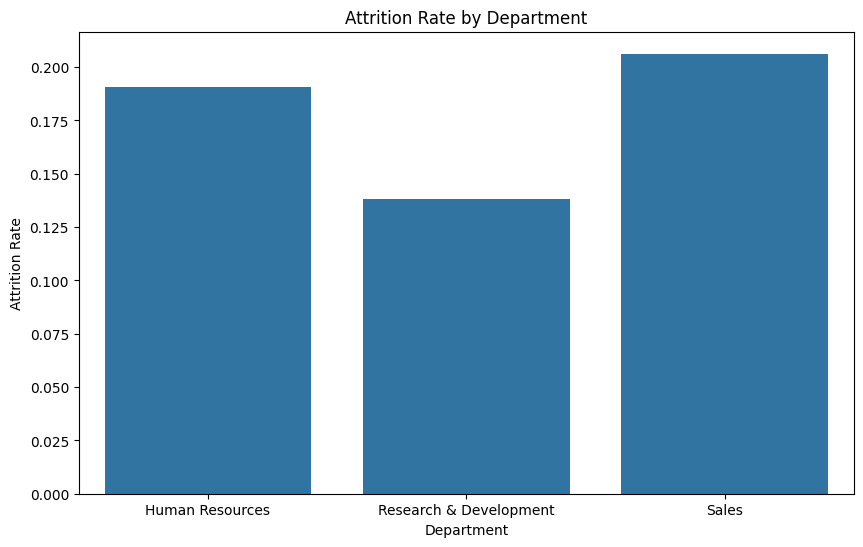


--- Attrition by Salary (MonthlyIncome) ---
Attrition           Attrition_Rate
MonthlyIncome_Bins                
Q1 (Lowest)               0.292683
Q2                        0.142077
Q3                        0.106267
Q4 (Highest)              0.103261


/tmp/ipykernel_5539/2724923582.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_attrition = df_eda.groupby('MonthlyIncome_Bins')['Attrition'].value_counts(normalize=True).unstack().fillna(0)


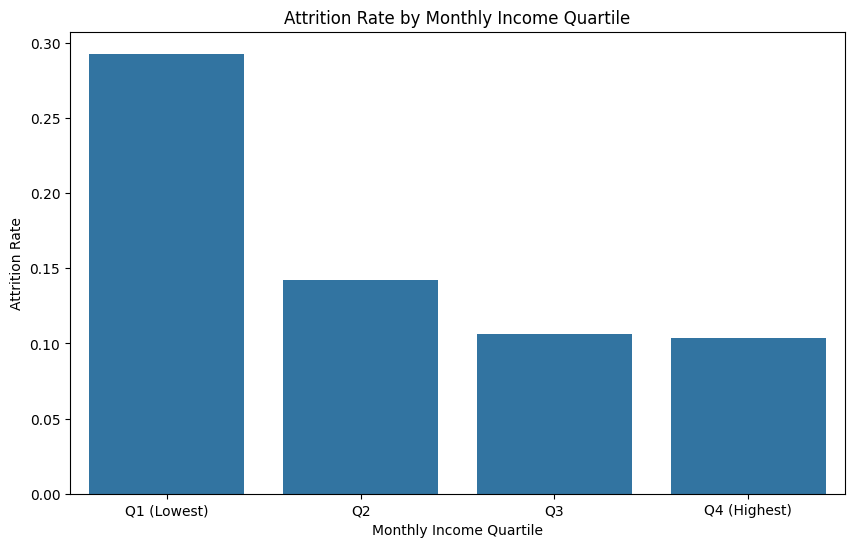


--- Gender-wise Attrition ---
Attrition  Attrition_Rate
Gender                   
Female           0.147959
Male             0.170068


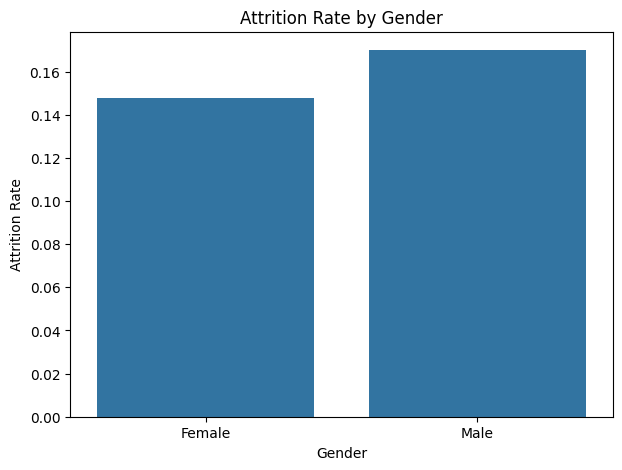


--- Age Distribution with Attrition ---


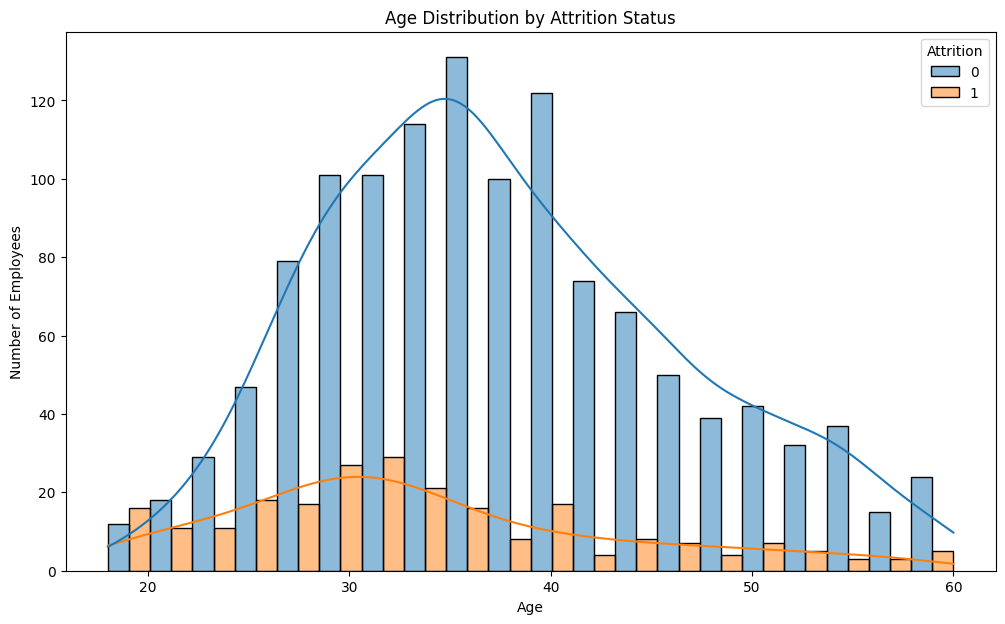


--- Overtime vs Attrition ---
Attrition  Attrition_Rate
OverTime                 
No               0.104364
Yes              0.305288


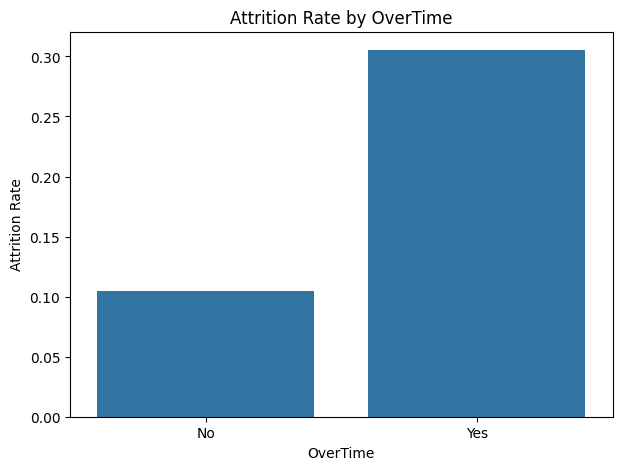


--- Job Satisfaction Analysis ---
Attrition        Attrition_Rate
JobSatisfaction                
1                      0.228374
2                      0.164286
3                      0.165158
4                      0.113290


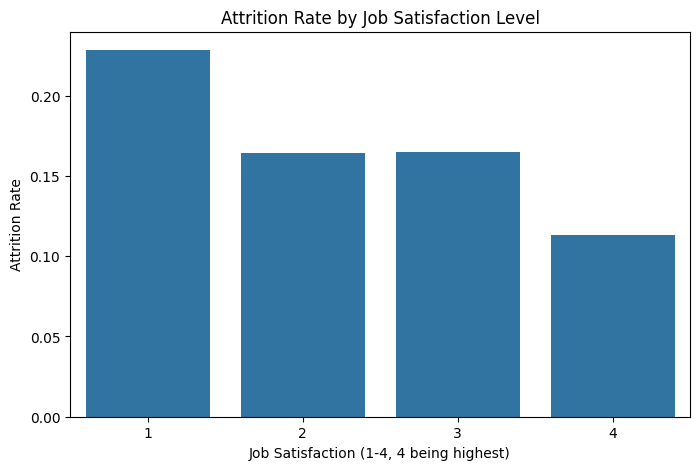


--- Correlation Heatmap (with Attrition) ---


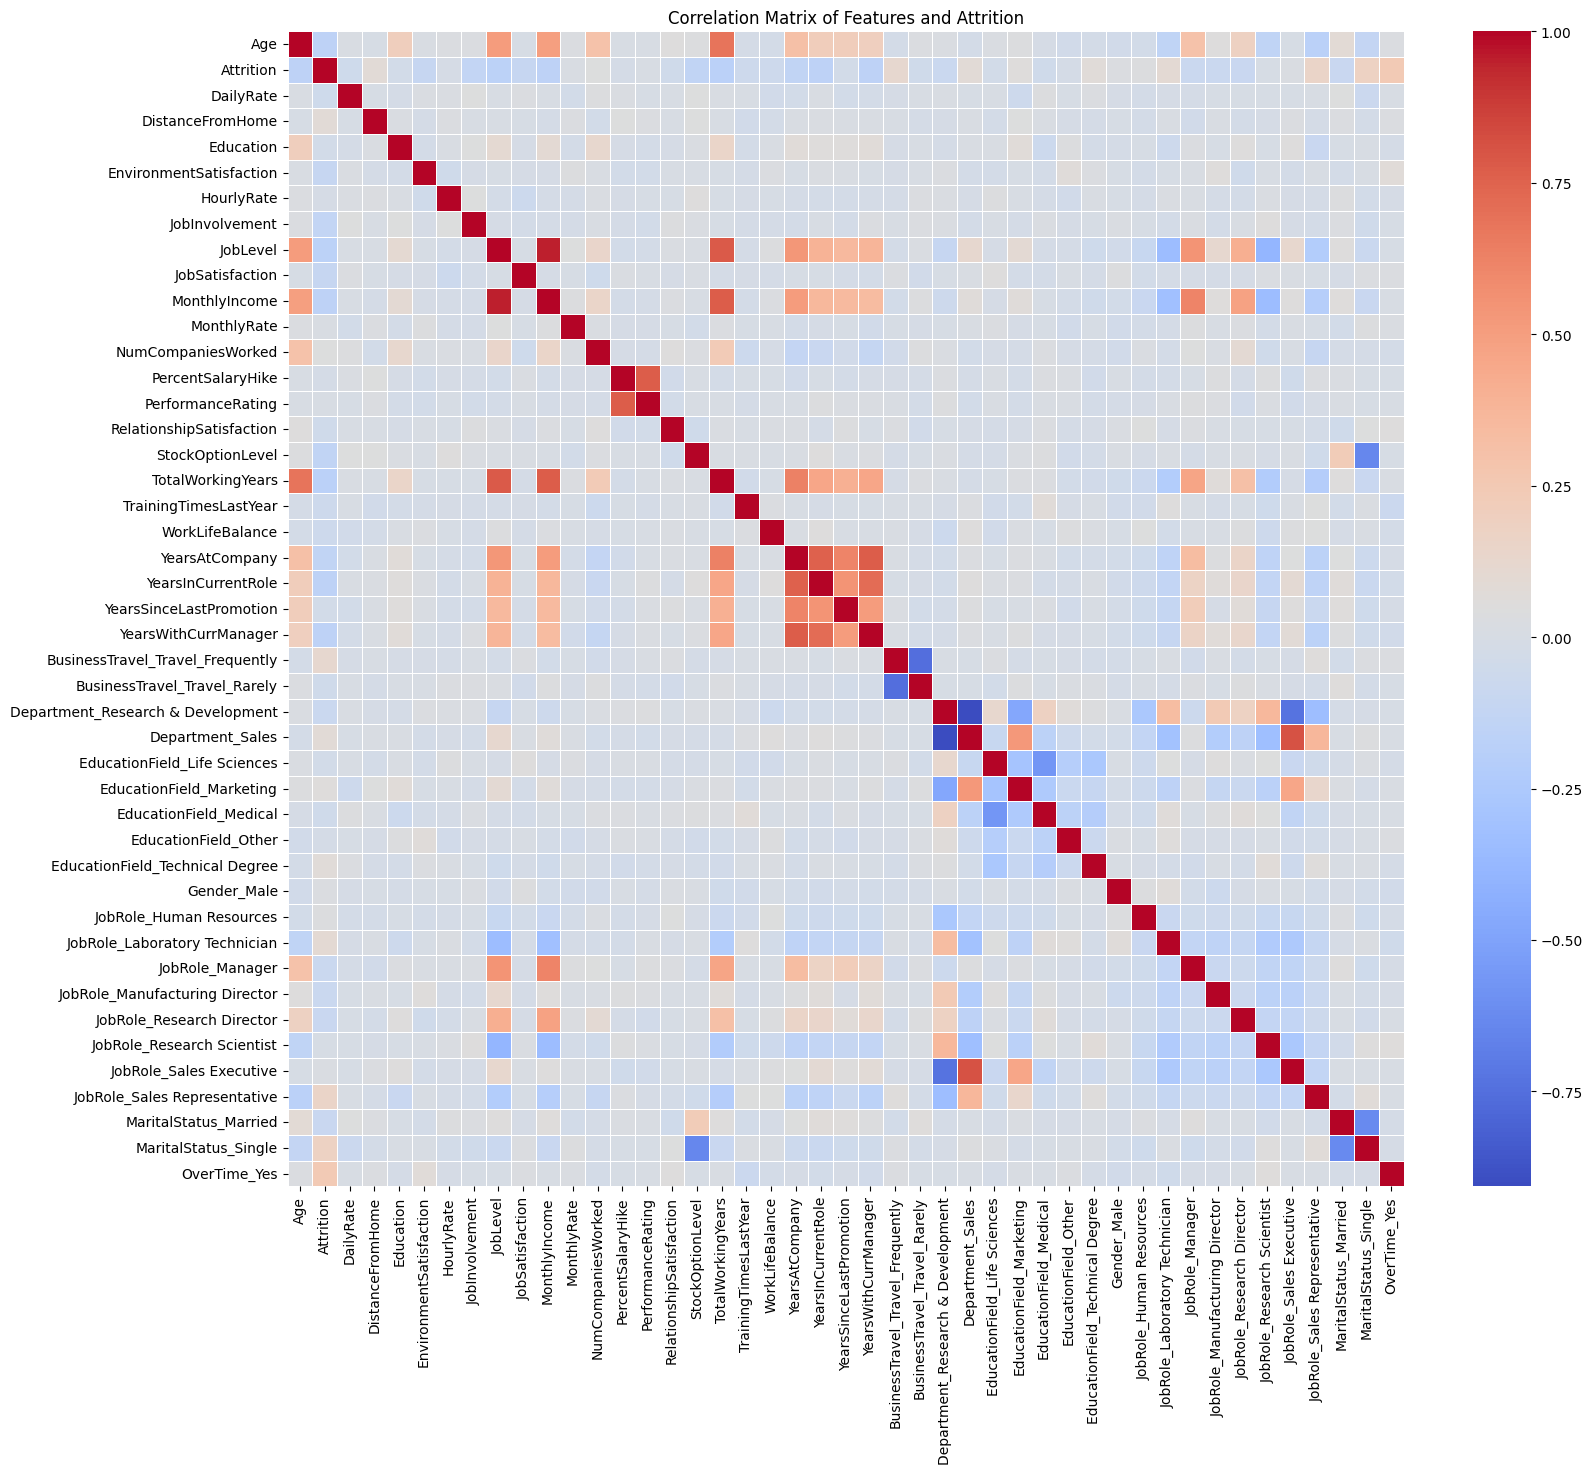


--- Top Correlations with Attrition ---
Attrition                            1.000000
OverTime_Yes                         0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender_Male                          0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.

In [ ]:
# Assuming df_eda is the DataFrame with original categorical columns
# and df is the preprocessed DataFrame with one-hot encoded columns
# and 'Attrition' mapped to 0/1.

# --- 1. Attrition by department ---
print("\n--- Attrition by Department ---")
department_attrition = df_eda.groupby('Department')['Attrition'].value_counts(normalize=True).unstack().fillna(0)
department_attrition['Attrition_Rate'] = department_attrition.get(1, 0) # Use .get(1, 0) to handle cases where '1' (Yes) might not exist
print(department_attrition[['Attrition_Rate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=department_attrition.index, y='Attrition_Rate', data=department_attrition)
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate')
plt.xlabel('Department')
plt.show()

# --- 2. Attrition by salary (MonthlyIncome) ---
print("\n--- Attrition by Salary (MonthlyIncome) ---")
# Create income bins for better visualization
df_eda['MonthlyIncome_Bins'] = pd.qcut(df_eda['MonthlyIncome'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
salary_attrition = df_eda.groupby('MonthlyIncome_Bins')['Attrition'].value_counts(normalize=True).unstack().fillna(0)
salary_attrition['Attrition_Rate'] = salary_attrition.get(1, 0)
print(salary_attrition[['Attrition_Rate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=salary_attrition.index, y='Attrition_Rate', data=salary_attrition)
plt.title('Attrition Rate by Monthly Income Quartile')
plt.ylabel('Attrition Rate')
plt.xlabel('Monthly Income Quartile')
plt.show()

# --- 3. Gender-wise attrition ---
print("\n--- Gender-wise Attrition ---")
gender_attrition = df_eda.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack().fillna(0)
gender_attrition['Attrition_Rate'] = gender_attrition.get(1, 0)
print(gender_attrition[['Attrition_Rate']])

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_attrition.index, y='Attrition_Rate', data=gender_attrition)
plt.title('Attrition Rate by Gender')
plt.ylabel('Attrition Rate')
plt.xlabel('Gender')
plt.show()

# --- 4. Age distribution ---
print("\n--- Age Distribution with Attrition ---")
plt.figure(figsize=(12, 7))
sns.histplot(df_eda, x='Age', hue='Attrition', multiple='dodge', bins=20, kde=True)
plt.title('Age Distribution by Attrition Status')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

# --- 5. Overtime vs attrition ---
print("\n--- Overtime vs Attrition ---")
overtime_attrition = df_eda.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack().fillna(0)
overtime_attrition['Attrition_Rate'] = overtime_attrition.get(1, 0)
print(overtime_attrition[['Attrition_Rate']])

plt.figure(figsize=(7, 5))
sns.barplot(x=overtime_attrition.index, y='Attrition_Rate', data=overtime_attrition)
plt.title('Attrition Rate by OverTime')
plt.ylabel('Attrition Rate')
plt.xlabel('OverTime')
plt.show()

# --- 6. Job satisfaction analysis ---
print("\n--- Job Satisfaction Analysis ---")
job_satisfaction_attrition = df_eda.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack().fillna(0)
job_satisfaction_attrition['Attrition_Rate'] = job_satisfaction_attrition.get(1, 0)
print(job_satisfaction_attrition[['Attrition_Rate']])

plt.figure(figsize=(8, 5))
sns.barplot(x=job_satisfaction_attrition.index, y='Attrition_Rate', data=job_satisfaction_attrition)
plt.title('Attrition Rate by Job Satisfaction Level')
plt.ylabel('Attrition Rate')
plt.xlabel('Job Satisfaction (1-4, 4 being highest)')
plt.show()

# --- 7. Correlation heatmap ---
print("\n--- Correlation Heatmap (with Attrition) ---")
# Select numerical and one-hot encoded boolean columns for correlation
# Use the preprocessed 'df' for this
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

cols_for_corr = [col for col in numerical_cols + bool_cols if col != 'EmployeeNumber'] # EmployeeNumber is an identifier, not a feature

correlation_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Attrition')
plt.show()

print("\n--- Top Correlations with Attrition ---")
attrition_correlations = correlation_matrix['Attrition'].sort_values(ascending=False)
print(attrition_correlations)

# --- Advanced Insights ---
print("\n--- Advanced Insights ---")
print("\nBased on the visualizations and correlations, we can infer some advanced insights:")
print("\n*   **High-Risk Employees:**")
print("    -   Employees in departments with higher attrition rates (e.g., Sales).")
print("    -   Employees in lower monthly income quartiles (Q1, Q2) tend to have higher attrition.")
print("    -   Employees working overtime show a significantly higher attrition rate.")
print("    -   Employees with lower Job Satisfaction (levels 1 and 2) are at higher risk.")
print("    -   Younger employees and those with fewer years at the company/current role, or since last promotion, may also be at higher risk (observable from Age distribution and correlation matrix). For example, check correlations for 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'.")

print("\n*   **Retention Patterns:**")
print("    -   Employees with higher Job Satisfaction and Work-Life Balance tend to stay (inverse of attrition risk).")
print("    -   Higher Monthly Income, Job Level, and having more Stock Options are generally associated with lower attrition.")
print("    -   Longer tenure (YearsAtCompany, TotalWorkingYears) and more stable roles (YearsInCurrentRole, YearsWithCurrManager) correlate with lower attrition.")

print("\n*   **Employee Behavior Trends:**")
print("    -   **Overtime and Attrition:** A strong trend shows overtime is a major predictor of attrition, suggesting burnout or dissatisfaction.")
print("    -   **Job Satisfaction:** Low job satisfaction is a key driver for employees to leave, highlighting the importance of workplace environment and role fulfillment.")
print("    -   **Income and Attrition:** Lower income brackets are associated with higher attrition, indicating financial factors play a role.")
print("    -   **Travel:** While not explicitly plotted here, `BusinessTravel_Travel_Frequently` often correlates positively with attrition (look at the correlation matrix). This suggests extensive travel might be a stressor.")
print("    -   **Job Role/Level:** Certain job roles or lower job levels might experience higher attrition, suggesting career development opportunities or role-specific challenges.")

In [15]:
# =========================================================
# 1. AGE GROUPS
# =========================================================

df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 65],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '55+'
    ]
)

# =========================================================
# 2. SALARY BANDS
# =========================================================

df['Salary Band'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000],
    labels=[
        'Low Salary',
        'Medium Salary',
        'High Salary',
        'Executive Salary'
    ]
)

# =========================================================
# 3. EXPERIENCE LEVELS
# =========================================================

df['Experience Level'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[0, 5, 10, 20, 40],
    labels=[
        'Entry Level',
        'Mid Level',
        'Senior Level',
        'Executive Level'
    ]
)

# =========================================================
# 4. EMPLOYEE TENURE GROUPS
# =========================================================

df['Employee Tenure Group'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 20, 40],
    labels=[
        'New Employee',
        'Junior Employee',
        'Experienced Employee',
        'Loyal Employee',
        'Veteran Employee'
    ]
)

# =========================================================
# 5. ATTRITION PERCENTAGE COLUMN
# =========================================================

total_employees = len(df)

df['Attrition Percentage'] = round(
    (df['Attrition'] / total_employees) * 100,
    2
)

# =========================================================
# 6. BUSINESS TRAVEL COLUMN
# =========================================================

df['BusinessTravel'] = np.select(
    [
        df['BusinessTravel_Travel_Frequently'] == 1,
        df['BusinessTravel_Travel_Rarely'] == 1
    ],
    [
        'Travel Frequently',
        'Travel Rarely'
    ],
    default='Non-Travel'
)

# =========================================================
# 7. DEPARTMENT COLUMN
# =========================================================

df['Department'] = np.select(
    [
        df['Department_Research & Development'] == 1,
        df['Department_Sales'] == 1
    ],
    [
        'Research & Development',
        'Sales'
    ],
    default='Human Resources'
)

# =========================================================
# 8. EDUCATION FIELD COLUMN
# =========================================================

df['EducationField'] = np.select(
    [
        df['EducationField_Life Sciences'] == 1,
        df['EducationField_Marketing'] == 1,
        df['EducationField_Medical'] == 1,
        df['EducationField_Other'] == 1,
        df['EducationField_Technical Degree'] == 1
    ],
    [
        'Life Sciences',
        'Marketing',
        'Medical',
        'Other',
        'Technical Degree'
    ],
    default='Human Resources'
)

# =========================================================
# 9. GENDER COLUMN
# =========================================================

df['Gender'] = np.where(
    df['Gender_Male'] == 1,
    'Male',
    'Female'
)

# =========================================================
# 10. JOB ROLE COLUMN
# =========================================================

df['JobRole'] = np.select(
    [
        df['JobRole_Human Resources'] == 1,
        df['JobRole_Laboratory Technician'] == 1,
        df['JobRole_Manager'] == 1,
        df['JobRole_Manufacturing Director'] == 1,
        df['JobRole_Research Director'] == 1,
        df['JobRole_Research Scientist'] == 1,
        df['JobRole_Sales Executive'] == 1,
        df['JobRole_Sales Representative'] == 1
    ],
    [
        'Human Resources',
        'Laboratory Technician',
        'Manager',
        'Manufacturing Director',
        'Research Director',
        'Research Scientist',
        'Sales Executive',
        'Sales Representative'
    ],
    default='Healthcare Representative'
)

# =========================================================
# 11. MARITAL STATUS COLUMN
# =========================================================

df['MaritalStatus'] = np.select(
    [
        df['MaritalStatus_Married'] == 1,
        df['MaritalStatus_Single'] == 1
    ],
    [
        'Married',
        'Single'
    ],
    default='Divorced'
)

# =========================================================
# 12. EMPLOYEE RISK CATEGORY
# =========================================================

conditions = [
    (
        (df['OverTime_Yes'] == 1) &
        (df['MonthlyIncome'] < 4000) &
        (df['JobSatisfaction'] <= 2)
    ),

    (
        (df['OverTime_Yes'] == 1) |
        (df['WorkLifeBalance'] <= 2)
    )
]

choices = [
    'High Risk',
    'Medium Risk'
]

df['Employee Risk Category'] = np.select(
    conditions,
    choices,
    default='Low Risk'
)

# =========================================================
# 13. BUSINESS KPIs
# =========================================================

# Attrition Rate
attrition_rate = round(
    (df['Attrition'].sum() / len(df)) * 100,
    2
)

# Average Salary
average_salary = round(
    df['MonthlyIncome'].mean(),
    2
)

# Retention Rate
retention_rate = round(
    100 - attrition_rate,
    2
)

# Overtime Employees Percentage
overtime_percentage = round(
    (df['OverTime_Yes'].sum() / len(df)) * 100,
    2
)

# Average Tenure
average_tenure = round(
    df['YearsAtCompany'].mean(),
    2
)

# =========================================================
# 14. KPI SUMMARY TABLE
# =========================================================

kpi_summary = pd.DataFrame({
    'KPI': [
        'Attrition Rate',
        'Average Salary',
        'Retention Rate',
        'Overtime Employees %',
        'Average Tenure'
    ],

    'Value': [
        f'{attrition_rate}%',
        f'${average_salary}',
        f'{retention_rate}%',
        f'{overtime_percentage}%',
        f'{average_tenure} Years'
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("=" * 60)
print("HR FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nKPI SUMMARY\n")
print(kpi_summary)

print("\nNEW FEATURE ENGINEERED COLUMNS\n")
print(df[[
    'Age Group',
    'Salary Band',
    'Experience Level',
    'Employee Tenure Group',
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'Employee Risk Category'
]].head())

# =========================================================
# SAVE FINAL DATASET
# =========================================================

df.to_csv(
    'cleaned_hr_attrition.csv',
    index=False
)

print("\nFinal dataset saved successfully!")
print("File Name: cleaned_hr_attrition.csv")

HR FEATURE ENGINEERING COMPLETED SUCCESSFULLY

KPI SUMMARY

                    KPI       Value
0        Attrition Rate      16.12%
1        Average Salary       $-0.0
2        Retention Rate      83.88%
3  Overtime Employees %       28.3%
4        Average Tenure  7.01 Years

NEW FEATURE ENGINEERED COLUMNS

  Age Group Salary Band Experience Level Employee Tenure Group  \
0     36-45         NaN        Mid Level  Experienced Employee   
1     46-55         NaN        Mid Level  Experienced Employee   
2     36-45         NaN        Mid Level                   NaN   
3     26-35         NaN        Mid Level  Experienced Employee   
4     26-35         NaN        Mid Level          New Employee   

      BusinessTravel              Department EducationField  Gender  \
0      Travel Rarely                   Sales  Life Sciences  Female   
1  Travel Frequently  Research & Development  Life Sciences    Male   
2      Travel Rarely  Research & Development          Other    Male   
3  Travel 